# Patterns in resource usage

Conda environment for this notebook: `conda env create`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)

The data was extracted from synthesis reports and structured in a seperate spreadsheet

In [25]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [26]:

import csv
with open("resource_usage_results.csv", newline="", encoding="utf-8") as csv_file:
    reader = csv.DictReader(csv_file)
    rows = [row for row in reader]

plot_rows = []
for row in rows:
    plot_rows.append({
        "ident": row.get("Identificator", "").strip(),
        "dataset": row.get("Identificator", "").strip().split(' ',1)[0],
        "ebop": float(row.get("EBOP")),
        "final_luts": float(row.get("FINAL LUTS")),
    })
print(plot_rows)

[{'ident': 'MNIST (52735)', 'dataset': 'MNIST', 'ebop': 52735.0, 'final_luts': 21858.0}, {'ident': 'MNIST (34304)', 'dataset': 'MNIST', 'ebop': 34304.0, 'final_luts': 16855.0}, {'ident': 'Jet-tagger (21624)', 'dataset': 'Jet-tagger', 'ebop': 21624.0, 'final_luts': 28159.0}, {'ident': 'Pixsplit (11698)', 'dataset': 'Pixsplit', 'ebop': 11698.0, 'final_luts': 29016.0}, {'ident': 'Jet-tagger (11634)', 'dataset': 'Jet-tagger', 'ebop': 11634.0, 'final_luts': 21018.0}, {'ident': 'Pixsplit (3640)', 'dataset': 'Pixsplit', 'ebop': 3640.0, 'final_luts': 23787.0}, {'ident': 'Jet-tagger (2895)', 'dataset': 'Jet-tagger', 'ebop': 2895.0, 'final_luts': 13982.0}, {'ident': 'Jet-tagger (1001)', 'dataset': 'Jet-tagger', 'ebop': 1001.0, 'final_luts': 12119.0}, {'ident': 'Pixsplit (864)', 'dataset': 'Pixsplit', 'ebop': 864.0, 'final_luts': 16559.0}, {'ident': 'Jet-tagger (303)', 'dataset': 'Jet-tagger', 'ebop': 303.0, 'final_luts': 10861.0}]


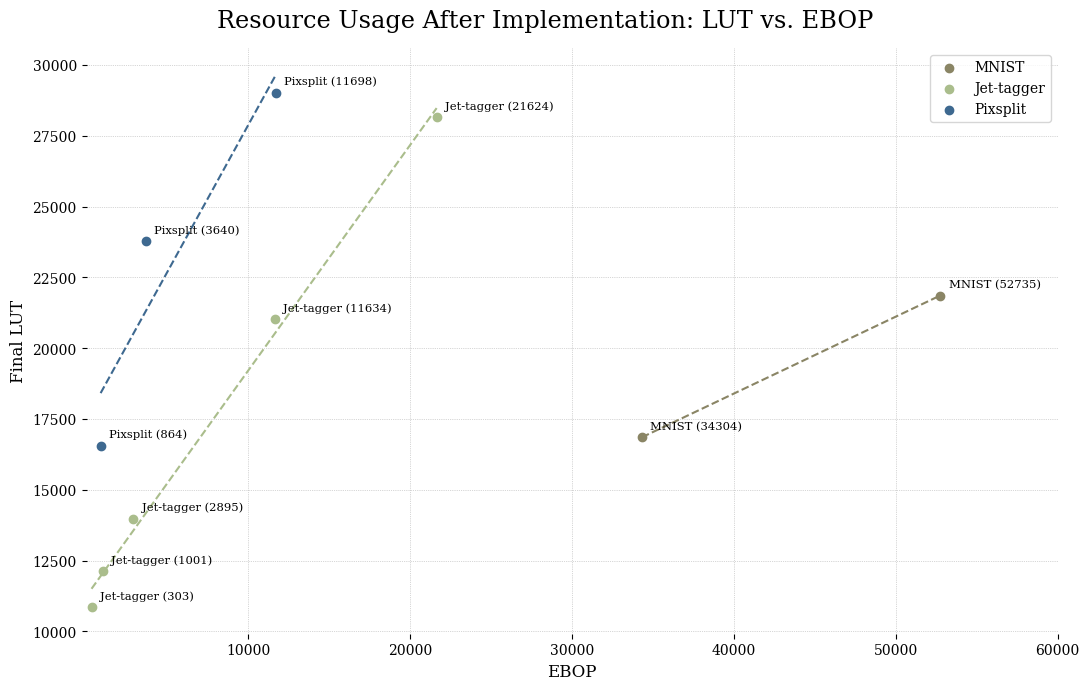

In [29]:
plotname = "Resource Usage After Implementation: LUT vs. EBOP"

styles = {
    "Pixsplit": {"label": "Pixsplit", "color": colors[0], "marker": "o"},
    "Jet-tagger": {"label": "Jet-tagger", "color":colors[1], "marker": "o"},
    "MNIST": {"label": "MNIST", "color": colors[2], "marker": "o"},
}

fig, ax = plt.subplots(figsize=(11, 7))

seen_labels = set()
for r in plot_rows:
    style = styles.get(r["dataset"])
    label = style["label"] if not style["label"] in seen_labels else None
    ax.scatter(r["ebop"], r["final_luts"], label=label, color=style["color"], marker=style["marker"])
    seen_labels.add(style["label"])

for dataset_name, style in styles.items():
    points = [(r["ebop"], r["final_luts"]) for r in plot_rows if r["dataset"] == dataset_name]
    if len(points) < 2:
        continue
    points.sort(key=lambda p: p[0])
    xs = np.array([p[0] for p in points], dtype=float)
    ys = np.array([p[1] for p in points], dtype=float)
    coeffs = np.polyfit(xs, ys, deg=1)
    x_line = np.linspace(xs.min(), xs.max(), 100)
    y_line = coeffs[0] * x_line + coeffs[1]
    ax.plot(x_line, y_line, color=style["color"], linestyle="--", linewidth=1.5)

for r in plot_rows:
    ax.annotate(
        r["ident"],
        (r["ebop"], r["final_luts"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize='small',
    )

ax.set_xlim(1, 60000)
ax.set_xlabel("EBOP",size='large')
ax.set_ylabel("Final LUT",size='large')
ax.grid(True, which="both", linestyle=":", linewidth=0.5)
ax.legend()


for spine in ("right", "top",
                "left", "bottom"
                ):
    ax.spines[spine].set_visible(False)

plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

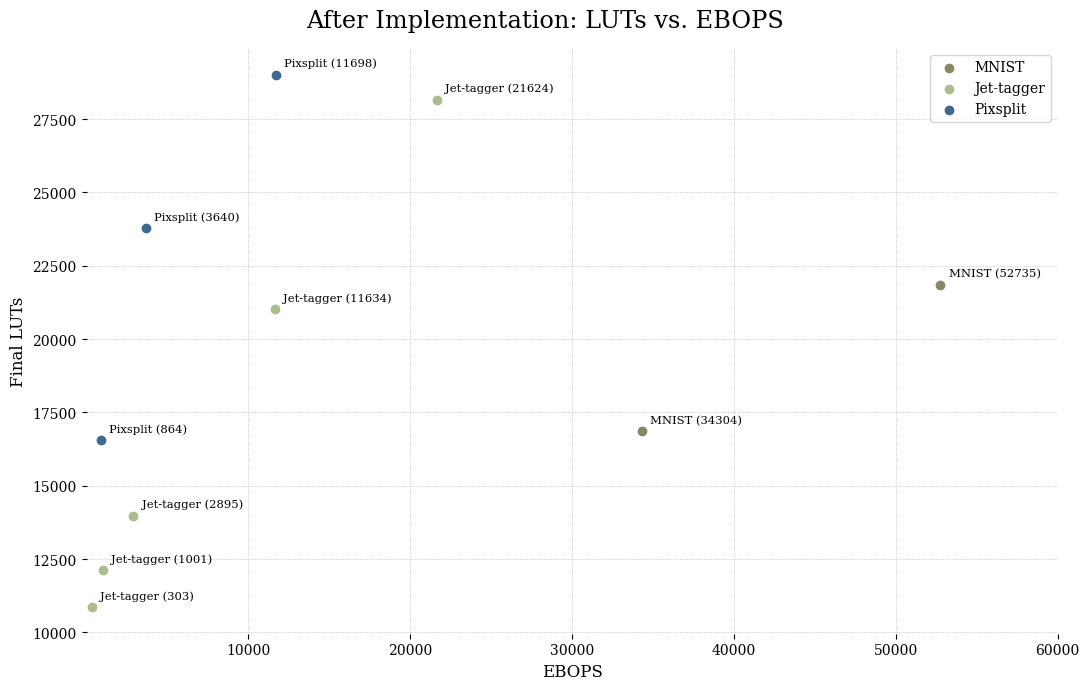

In [23]:
plotname = "After Implementation: LUTs vs. EBOPS"

styles = {
    "Pixsplit": {"label": "Pixsplit", "color": colors[0], "marker": "o"},
    "Jet-tagger": {"label": "Jet-tagger", "color":colors[1], "marker": "o"},
    "MNIST": {"label": "MNIST", "color": colors[2], "marker": "o"},
}

fig, ax = plt.subplots(figsize=(11, 7))

seen_labels = set()
for r in plot_rows:
    style = styles.get(r["dataset"])
    label = style["label"] if not style["label"] in seen_labels else None
    ax.scatter(r["ebop"], r["final_luts"], label=label, color=style["color"], marker=style["marker"])
    seen_labels.add(style["label"])

for r in plot_rows:
    ax.annotate(
        r["ident"],
        (r["ebop"], r["final_luts"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize='small',
    )

ax.set_xlim(1, 60000)
ax.set_xlabel("EBOPS",size='large')
ax.set_ylabel("Final LUTs",size='large')
ax.grid(True, which="both", linestyle=":", linewidth=0.5)
ax.legend()


for spine in ("right", "top",
                "left", "bottom"
                ):
    ax.spines[spine].set_visible(False)

plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")